# SL-13b : TPR x SAE — deux lectures des mêmes états cachés

**Phase 5 -- Neuro-symbolique** | Précédent : [SL-13 (diagnostic TPR)](SL-13-Discover-TPR.ipynb) --> SL-13b --> Suivant : [SL-14 (AI Feynman)](SL-14-AIFeynman-Discover-Equations.ipynb) | [Index](../README.md)

***

**Référence** : R. Thomas McCoy, Paul Soulos, Tal Linzen, Paul Smolensky, *The Emergent Symbolic Structure of Artificial Neural Networks*, arXiv:2608.29530 — suite directe de SL-13. Organe SAE : module `ict.sae_dictionary` de la série ICT (entraînement top-k, issue #15480), invoqué tel quel.

***

SL-13 a demandé si un GRU entraîné sur des tâches symboliques développe une **structure TPR** (Tensor Product Representation : `somme_t role(t) (X) filler(x_t)`) — et a répondu de façon bornée : structure *approximative et fonctionnellement exploitée*, pas mécanisme exact. Ce notebook confronte cette lecture à une **seconde lecture concurrente des mêmes états cachés** : un **dictionnaire creux** (Sparse Autoencoder top-k), l'outil de référence pour demander à un réseau « quels concepts linéaires utilises-tu ? ».

La confrontation est **mesurée, pas rhétorique**. Les deux lectures factorisent le même objet `H` (l'état caché final de l'encodeur GRU, après lecture de toute la séquence) :

| Lecture | Structure imposée | Ce qu'elle affirme |
|---------|-------------------|--------------------|
| **TPR** (SL-13) | somme de produits tensoriels role (X) filler | « H additionne des paires (position, symbole) liées » |
| **SAE top-k** (ICT) | combinaison creuse d'atomes d'un dictionnaire appris | « H active quelques atomes, chacun porteur d'un facteur » |

Si la structure TPR est réelle, alors les atomes du dictionnaire qui portent un facteur (position, symbole) devraient être **approximativement de rang 1** dans le découpage (d_role x d_filler) de la TPR — car une paire role (X) filler est précisément une matrice de rang 1. C'est une prédiction falsifiable : si elle n'est pas soutenue, la structure TPR n'est pas ce que le dictionnaire voit dans H.

## Plan

1. **Tâche et GRU** : copy (8 symboles, longueur 5), protocole de décodage à BOS (chaque position est une cible), même architecture que SL-13
2. **Lecture TPR** : décomposition role x filler au rang demandé 5, plafonné par le découpage (4 en 4 x 8) ; deux gardes mesurées ; découpage de lecture 4 x 8 par convention
3. **Lecture SAE** : dictionnaire top-k sur-complet entraîné par l'organe `ict.sae_dictionary`
4. **Confrontation statistique** : sélectivité des features aux facteurs (position, symbole), contre un null apparié en effectifs
5. **Confrontation géométrique** : concentration de rang 1 des atomes dédiés vs non dédiés, contre des directions aléatoires
6. **Confrontation fonctionnelle** : permutation de blocs de coordonnées dans le découpage TPR (contrôle structurel — ce n'est **pas** une intervention sur des rôles appris) contre ablation sélective SAE, réinjection dans le décodeur
7. **Généralisation** : le dictionnaire appris sur train, appliqué à val (encode-only) contre les reconstructions TPR

**Bornage** (hérité de l'EPIC #14366) : tout résultat ci-dessous est une *évidence descriptive* à échelle CPU — jamais la preuve qu'un mécanisme est identifié ; les écarts rapportés sont des écarts entre moyennes et dispersions sur tirages, **pas des tests inférentiels** ; GWT et tout modèle à grande échelle restent hors scope.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # determinisme cuBLAS (#16795)
# Determinisme (#16795) : la graine seule ne garantit PAS la reproductibilite.
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import torch.nn as nn
import torch.nn.functional as F

# Organe SAE de la serie ICT (issue #15480) : le notebook invoque le module
# reel -- top-k SAE, decodeur unit-norm, selectivite contre null apparie --
# il ne reimplemente rien. Resolution robuste depuis le cwd d'execution.
_cwd = Path.cwd()
ICT_DIR = None
for _base in [_cwd, *_cwd.parents]:
    _probe = _base / "MyIA.AI.Notebooks" / "IIT" / "ICT-Series"
    if (_probe / "ict" / "sae_dictionary.py").exists():
        ICT_DIR = _probe
        break
if ICT_DIR is None:
    raise RuntimeError("ICT-Series introuvable : executer le notebook depuis l'arbre du depot CoursIA")
sys.path.insert(0, str(ICT_DIR))
from ict.sae_dictionary import train_sae, factor_selectivity
from ict.sae_calibration import fraction_variance_unexplained

print(f"numpy {np.__version__} | matplotlib {matplotlib.__version__} | torch {torch.__version__}")
print("device = cpu | organe : ict/sae_dictionary.py (serie ICT, SAE top-k sur-complet)")

torch.manual_seed(0)
np.random.seed(0)

numpy 2.4.4 | matplotlib 3.10.8 | torch 2.11.0+cpu
device = cpu | organe : ict/sae_dictionary.py (serie ICT, SAE top-k sur-complet)


### Protocole — une expérience, deux lectures, quatre questions

L'expérience unique : un GRU une couche (`d_model = 32`, identique à SL-13) apprend la tâche **copy** sur 800 séquences de 5 symboles tirés d'un vocabulaire de 8 lettres. On collecte `H` — l'état caché final de l'encodeur après lecture de toute la séquence — sur train et sur val.

**Protocole de décodage à BOS** : l'entrée du décodeur est `[BOS, s0, s1, s2, s3]` et la cible est la séquence complète `[s0..s4]`. Chaque position — y compris la position 0 — est donc une **cible de prédiction**, et à l'étape t le décodeur n'a consommé que BOS et (pour t >= 1) les symboles s0..s(t-1) : le symbole cible n'est jamais présent dans son entrée au moment où il doit le produire, il ne peut venir que de `H`. L'évaluation (comme l'entraînement) reste *teacher-forced* — le décodeur voit les symboles précédents — convention du harnais SL-13, valable pour comparer des lectures entre elles, pas une mesure de génération libre.

Pourquoi copy : le décodage doit produire chaque symbole à sa position. `H` doit porter l'information de chaque symbole sous une forme que le décodeur peut lire étape par étape — la décomposition en **40 facteurs (position t, symbole c)** est l'*hypothèse d'organisation* que les deux lectures concurrentes prétendent capturer ; c'est une hypothèse testée, pas une nécessité logique démontrée.

Les quatre questions :

1. **Statistique** — le dictionnaire SAE contient-il des features *dédiées* à des facteurs (position, symbole) ? Mesure descriptive : AUC de Mann-Whitney par feature contre chaque label binaire, z-score contre 200 relabelisations aléatoires appariées en effectifs.
2. **Géométrie** — les atomes dédiés à un facteur sont-ils plus *proches du rang 1* (au sens du découpage TPR) que les atomes non dédiés et que des directions aléatoires ? C'est le pont prédit par l'hypothèse TPR : role (X) filler est de rang 1.
3. **Fonctionnelle** — la permutation des deux premiers blocs de coordonnées du découpage TPR (contrôle structurel du découpage, **pas** une intervention sur des rôles appris) et l'ablation SAE des features dédiées à la position 0 produisent-elles des chutes d'accuracy comparables, chacune contre son contrôle apparié ?
4. **Généralisation** — le dictionnaire appris sur train transfère-t-il à val (FVU encode-only, réinjection) mieux que la TPR partagée ?

Hypothèse nulle commune : aucune des deux lectures ne voit rien de structure — les z de sélectivité restent proches du null, les atomes dédiés ne se distinguent pas du contrôle aléatoire.

In [2]:
VOCAB = list("abcdefgh")
SEQ_LEN = 5
TRAIN_SAMPLES = 800
VAL_SAMPLES = 200


def make_copy_task(seq_len=SEQ_LEN, n_samples=200, seed=0):
    """Copy : la sortie est l'entree -- le reseau doit retenir quelle lettre etait ou."""
    rng = np.random.RandomState(seed)
    samples = []
    for _ in range(n_samples):
        s = "".join(rng.choice(VOCAB, size=seq_len))
        samples.append((s, s))
    return samples


train_data = make_copy_task(n_samples=TRAIN_SAMPLES, seed=0)
val_data = make_copy_task(n_samples=VAL_SAMPLES, seed=999)
print(f"Exemples copy : {train_data[:3]}")
print(f"train = {len(train_data)} sequences | val = {len(val_data)} sequences | vocabulaire = {len(VOCAB)} lettres")

Exemples copy : [('ehfad', 'ehfad'), ('ddhbd', 'ddhbd'), ('fcehg', 'fcehg')]
train = 800 sequences | val = 200 sequences | vocabulaire = 8 lettres


### Lecture du modèle — même GRU que SL-13, protocole BOS en plus

Architecture reprise telle quelle de SL-13 : encodeur GRU une couche, décodeur GRU, head linéaire sur le vocabulaire. `d_model = 32`, 60 époques, Adam `lr = 1e-2`, CPU. Deux différences assumées par rapport au harnais SL-13 : l'entrée du décodeur est préfixée par BOS et la cible est la séquence complète — ainsi la position 0 est une cible de prédiction (dans SL-13, `tgt[:, :-1]` prédisait `tgt[:, 1:]` : la position 0 n'était jamais prédite et servait seulement d'entrée, et le premier symbole prédit l'était en voyant la position 0 dans l'entrée). La comparabilité de l'*architecture* est conservée ; le protocole de mesure est corrigé.

In [3]:
BOS, EOS, PAD = "<bos>", "<eos>", "<pad>"
SYMBOLS = [BOS, EOS, PAD] + VOCAB
SYM2IDX = {s: i for i, s in enumerate(SYMBOLS)}
V = len(SYMBOLS)
D_MODEL = 32
N_EPOCHS = 60


class SeqTaskGRU(nn.Module):
    """Encodeur GRU + decodeur GRU, head de sortie sur le vocabulaire (identique SL-13)."""

    def __init__(self, vocab_size, d_model=32, n_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.encoder = nn.GRU(d_model, d_model, num_layers=n_layers, batch_first=True)
        self.decoder = nn.GRU(d_model, d_model, num_layers=n_layers, batch_first=True)
        self.head = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def encode(self, x):
        e = self.embed(x)
        _, h = self.encoder(e)
        return h

    def forward(self, src, dec_in):
        h = self.encode(src)
        e_in = self.embed(dec_in)
        out, _ = self.decoder(e_in, h[-1:])
        return self.head(out)


def encode_batch(samples, device):
    """src = sequence ; dec_in = [BOS] + seq[:-1] ; dec_out = sequence complete.

    Protocole BOS : chaque position de dec_out est une cible, et le symbole cible
    n'est jamais present dans dec_in au moment ou il est predit.
    """
    src = torch.tensor([[SYM2IDX[c] for c in s] for s, _ in samples], device=device)
    dec_in = torch.tensor(
        [[SYM2IDX[BOS]] + [SYM2IDX[c] for c in t[:-1]] for _, t in samples], device=device
    )
    dec_out = torch.tensor([[SYM2IDX[c] for c in t] for _, t in samples], device=device)
    return src, dec_in, dec_out


def train_gru(samples_train, samples_val, n_epochs=40, d_model=32, lr=1e-2, seed=0):
    torch.manual_seed(seed)
    device = torch.device("cpu")
    model = SeqTaskGRU(V, d_model=d_model).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(n_epochs):
        model.train()
        src, dec_in, dec_out = encode_batch(samples_train, device)
        logits = model(src, dec_in)
        loss = F.cross_entropy(logits.reshape(-1, V), dec_out.reshape(-1))
        opt.zero_grad()
        loss.backward()
        opt.step()
        model.eval()
        with torch.no_grad():
            src_v, dec_in_v, dec_out_v = encode_batch(samples_val, device)
            v_logits = model(src_v, dec_in_v)
            v_acc = (v_logits.argmax(-1) == dec_out_v).float().mean().item()
        history.append((epoch, loss.item(), v_acc))
    return model, history


def collect_hidden(model, samples):
    model.eval()
    with torch.no_grad():
        src, _, _ = encode_batch(samples, torch.device("cpu"))
        h = model.encode(src)
    return h[-1].cpu().numpy()


def accuracy_with_h(model, samples, H_init):
    """Evalue l'accuracy quand on force l'etat cache initial du decodeur a H_init."""
    model.eval()
    with torch.no_grad():
        src, dec_in, dec_out = encode_batch(samples, torch.device("cpu"))
        e_in = model.embed(dec_in)
        # np.ascontiguousarray : H_init peut etre une vue broadcast read-only --
        # from_numpy sur un array non-writable emet un warning qui fuiterait un
        # chemin machine dans les outputs.
        h_init = torch.from_numpy(np.ascontiguousarray(H_init)).float().unsqueeze(0)
        out, _ = model.decoder(e_in, h_init)
        logits = model.head(out)
        acc = (logits.argmax(-1) == dec_out).float().mean().item()
    return acc


t0 = time.time()
model, hist = train_gru(train_data, val_data, n_epochs=N_EPOCHS, d_model=D_MODEL, seed=0)
t_train = time.time() - t0
val_acc = hist[-1][2]
print(f"copy (protocole BOS) | epochs={N_EPOCHS} | train_time={t_train:.2f}s | val_acc={val_acc:.3f} (hasard = {1.0 / V:.3f})")

H_train = collect_hidden(model, train_data)
H_val = collect_hidden(model, val_data)
print(f"H_train {H_train.shape} | H_val {H_val.shape}")

copy (protocole BOS) | epochs=60 | train_time=2.59s | val_acc=0.817 (hasard = 0.091)
H_train (800, 32) | H_val (200, 32)


### Lecture du résultat d'entraînement

**Sortie obtenue** : `val_acc = 0.817` sous le protocole BOS (hasard par token = 1/11 = 0.091, entraînement en ~2 s CPU). Le protocole fait de *chaque position* une cible : à l'étape t, le décodeur a consommé BOS et les premiers symboles — le symbole cible (position t) n'est jamais dans son entrée au moment où il doit le produire, donc il ne peut venir que de `H`. La position 0 elle-même n'est produite qu'à partir de BOS et de `H`.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| val_acc (teacher-forced) | 0.817 sur 5 positions | décodage correct ~4 fois sur 5 — l'information utile passe par `H` |
| hasard par token | 1/11 = 0.091 | 0.817 est très au-dessus du hasard, à ~0.18 d'une lecture parfaite |
| budget | ~2 s CPU | tient dans le budget d'un notebook |

**Points clés** :

1. Ce que le chiffre *établit* : l'information nécessaire au décodage passe par l'état caché final `H` — le décodeur ne voit jamais le symbole qu'il prédit, et les séquences de val sont nouvelles (0.817 ne peut pas venir d'une mémorisation mot à mot). C'est un fait de *passage d'information*, pas encore une affirmation sur sa *forme* — c'est précisément ce que les deux lectures concurrentes vont se disputer.
2. Nuance de protocole : l'évaluation (comme l'entraînement) est *teacher-forced* — le décodeur voit les symboles précédents. Le score sert à comparer des lectures entre elles sur le même banc ; il ne qualifie pas la génération libre.
3. Ne pas comparer ce 0.817 au 0.835 de SL-13 : le protocole diffère (SL-13 ne prédisait pas la position 0). La comparabilité porte sur l'architecture et la tâche, pas sur le scalaire d'accuracy.
4. La suite : la *forme* de l'information dans `H` — objet de la lecture TPR, puis de la lecture SAE.

In [4]:
def decompose_tpr(y, d_role, d_filler, bias_dim=0, rank=None):
    """Approxime chaque echantillon y[n] par une TPR de rang contraint (identique SL-13).

    Modele : body[n, r, f] = sum_g R[n, r, g] * F[n, g, f], SVD tronquee au rang k
    demande par echantillon. rank=None => rang plein (factorisation exacte, R^2 = 1).
    Retourne (roles_mean, fillers_mean, residual_norm_moyen, r2_moyen).
    """
    dim = d_role * d_filler
    if y.shape[-1] != dim + bias_dim:
        raise ValueError(f"y dim {y.shape[-1]} != d_role*d_filler + bias_dim = {dim + bias_dim}")
    body = y[..., :dim].reshape(-1, d_role, d_filler)
    n = body.shape[0]
    k_full = min(d_role, d_filler)
    k = min(rank, k_full) if rank is not None else k_full
    k = max(k, 1)
    R_list = []
    F_list = []
    resid_norms = []
    yss_total = 0.0
    rss_total = 0.0
    for i in range(n):
        M = body[i]
        U, s, Vt = np.linalg.svd(M, full_matrices=False)
        sqrt_s = np.sqrt(np.maximum(s[:k], 0))
        R_i = U[:, :k] * sqrt_s[None, :]
        F_i = sqrt_s[:, None] * Vt[:k, :]
        R_list.append(R_i)
        F_list.append(F_i)
        approx = np.einsum("rg,gf->rf", R_i, F_i)
        res = float(np.linalg.norm(M - approx))
        resid_norms.append(res)
        yss_total += float(np.sum(M ** 2))
        rss_total += float(np.sum((M - approx) ** 2))
    R_mean = np.mean(R_list, axis=0)
    F_mean = np.mean(F_list, axis=0)
    residual_mean = float(np.mean(resid_norms))
    r2 = 1.0 - rss_total / max(yss_total, 1e-12)
    return R_mean, F_mean, residual_mean, r2


# Garde de trivialite (documentee par SL-13) : pour TOUT split, la SVD par
# echantillon tronquee a k = min(d_role, d_filler) est exacte -- le R^2 vaut 1
# partout et le scan par R^2 ne dit rien. On le mesure une fois pour l'exposer.
# Second critere essaye : la reinjection de la TPR PARTAGEE (R_mean, F_mean
# appris sur train) -- mesuree aussi, et elle s'effondre pour TOUS les splits
# (une seule reconstruction pour toutes les sequences : le decodeur ne peut
# rien relire). Les deux scans sont donc rapportes comme des gardes, et le
# decoupage de lecture est fixe PAR CONVENTION documentee : 4x8, heritage du
# white-box de SL-13 (4x4 sur d_model=16), 4 coordonnees de role et 8 de filler.
TPR_RANK = SEQ_LEN  # 5 paires role-filler demandees (plafonnees par le decoupage)

splits = []
for d_role in range(1, D_MODEL + 1):
    if D_MODEL % d_role != 0:
        continue
    d_filler = D_MODEL // d_role
    k = min(TPR_RANK, min(d_role, d_filler))
    _, _, _, r2 = decompose_tpr(H_train, d_role, d_filler, rank=k)
    splits.append((d_role, d_filler, k, r2))


def shared_tpr_acc(d_role, d_filler):
    """TPR partagee (train) reinjectee telle quelle sur val."""
    R_m, F_m, _, _ = decompose_tpr(H_train, d_role, d_filler, rank=TPR_RANK)
    shared = np.einsum("rg,gf->rf", R_m, F_m).flatten()
    return accuracy_with_h(model, val_data, np.broadcast_to(shared, H_val.shape))


shared_accs = {(dr, df): shared_tpr_acc(dr, df) for dr, df, _, _ in splits}

# Convention de lecture (voir interpretation) : white-box 4x8, heritage SL-13.
D_ROLE, D_FILLER = 4, D_MODEL // 4
R_mean, F_mean, _, r2_best = decompose_tpr(H_train, D_ROLE, D_FILLER, rank=TPR_RANK)


def tpr_reconstruct(H, d_role, d_filler, rank, permute_blocs=False):
    """Reconstruit chaque echantillon par SA propre factorisation tronquee.

    permute_blocs=True echange les lignes 0 et 1 de R_i avant reconstruction :
    c'est la permutation des deux premiers BLOCS DE COORDONNEES du decoupage
    (controle structurel du decoupage) -- pas une intervention sur des roles
    appris, que ce decoupage ne fournit pas.
    """
    out = np.zeros_like(H)
    for i in range(H.shape[0]):
        R_i, F_i, _, _ = decompose_tpr(H[i], d_role, d_filler, rank=rank)
        if permute_blocs and d_role >= 2:
            R_i = R_i.copy()
            R_i[[0, 1]] = R_i[[1, 0]]
        out[i] = np.einsum("rg,gf->rf", R_i, F_i).flatten()
    return out


print(f"Deux gardes mesurees sur les splits de d_model={D_MODEL} (rang k = min({TPR_RANK}, min(d_role, d_filler)))")
print(f"{'split':>9s} {'rang':>5s} {'R^2':>8s}   {'acc TPR partagee (val)':>24s}")
for d_role, d_filler, k, r2 in splits:
    marker = "   <-- decoupage conventionnel" if (d_role, d_filler) == (D_ROLE, D_FILLER) else ""
    print(f"{d_role:>4d}x{d_filler:<4d} {k:>5d} {r2:>8.4f}   {shared_accs[(d_role, d_filler)]:>24.3f}{marker}")
print(f"Decoupage de lecture retenu ({D_ROLE} x {D_FILLER}, convention) : roles moyens {R_mean.shape}, fillers moyens {F_mean.shape}")

Deux gardes mesurees sur les splits de d_model=32 (rang k = min(5, min(d_role, d_filler)))
    split  rang      R^2     acc TPR partagee (val)
   1x32       1   1.0000                      0.127
   2x16       2   1.0000                      0.138
   4x8        4   1.0000                      0.135   <-- decoupage conventionnel
   8x4        4   1.0000                      0.134
  16x2        2   1.0000                      0.131
  32x1        1   1.0000                      0.139
Decoupage de lecture retenu (4 x 8, convention) : roles moyens (4, 4), fillers moyens (4, 8)


### Lecture du scan TPR — deux gardes plates, un découpage par convention

**Sortie obtenue** : les deux critères essayés pour sélectionner un découpage sont **plats** :

| Garde | Mesure | Ce qu'elle établit |
|-------|--------|--------------------|
| R² par échantillon (rang k) | 1.0000 pour tous les splits | la SVD par échantillon tronquée à k = min(d_role, d_filler) est *exacte* — le scan par R² ne peut rien sélectionner |
| acc de la TPR *partagée* (train vers val) | 0.127–0.139 pour tous les splits | une seule reconstruction (R̄, F̄) pour toutes les séquences ne peut rien faire relire au décodeur — échec plat, aucun split ne s'en sauve |

**Points clés** :

1. Aucun critère mesuré ne sélectionne un découpage : le constat de SL-13 se répète ici. Le découpage de lecture est donc **fixé par convention documentée** : **4 x 8**, héritage du white-box de SL-13 (4 x 4 sur d_model = 16). Ce choix est déclaré, pas dérivé — et un découpage dégénéré (1 x 32) rendrait toute mesure de rang 1 vacuous, c'est pourquoi il n'est pas utilisé.
2. Limite structurelle assumée : dans un découpage 4 x 8, le rang maximal d'une matrice est min(4, 8) = 4 — le `TPR_RANK = 5` demandé y est *plafonné*. Une TPR à 5 rôles distincts demanderait un découpage à au moins 5 lignes (par exemple 8 x 4, où 5 est atteignable) — mais la sélection resterait tout aussi conventionnelle, faute de critère mesuré.
3. Conséquence pour la suite : la TPR *partagée* est le seul transfert train vers val côté TPR (résultat effondré, cellule de généralisation) ; les factorisations par échantillon, exactes par construction, servent de plafond local et de représentation de lecture, pas de prédiction.
4. C'est le premier résultat croisé de la confrontation : là où la lecture SAE *apprend un vocabulaire* réutilisable, la TPR ne dispose d'aucun objet appris partageable à ce découpage — cette asymétrie reviendra à la cellule de généralisation.

In [5]:
N_FEATURES = 64   # sur-complet x2 en d_model = 32
K_SPARSE = 8      # au plus 8 atomes actifs par sequence
N_STEPS = 400

sae_out = train_sae(H_train, n_features=N_FEATURES, k=K_SPARSE, seed=0, n_steps=N_STEPS, lr=0.05)
sae = sae_out["sae"]
z_train = sae_out["codes"]
z_val = sae.encode(H_val)
H_sae_val = sae.decode(z_val)
fvu_val = fraction_variance_unexplained(H_val, H_sae_val)

print(f"SAE top-k (k={K_SPARSE}) | atomes = {N_FEATURES} (sur-complet x{N_FEATURES // D_MODEL}) | {N_STEPS} pas full-batch")
print(f"FVU train = {sae_out['fvu']:.4f} | L0 train = {sae_out['l0']:.2f} (borne <= {K_SPARSE})")
print(f"FVU val (dictionnaire fige, encode-only) = {fvu_val:.4f}")
print(f"codes train {z_train.shape} | codes val {z_val.shape}")

SAE top-k (k=8) | atomes = 64 (sur-complet x2) | 400 pas full-batch
FVU train = 0.0746 | L0 train = 8.00 (borne <= 8)
FVU val (dictionnaire fige, encode-only) = 0.1032
codes train (800, 64) | codes val (200, 64)


### Lecture de l'entraînement SAE

**Sortie obtenue** : le dictionnaire top-k sur-complet (64 atomes pour d = 32) reconstruit `H` en laissant non expliqués ~7,5 % de la variance en train et ~10 % en val, en activant au plus 8 atomes par séquence.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| FVU train | ~0.075 | le dictionnaire couvre l'essentiel de la variance de H |
| L0 <= 8 | borne top-k | chaque séquence est décrite par peu d'atomes |
| FVU val | ~0.10 | le dictionnaire transfère sans sur-ajustement massif (écart train/val ~0.03) |

**Points clés** :

1. L'organe `ict.sae_dictionary` documente sa limite mesurée : sur corpus exactement reconstructible, l'entraînement full-batch recouvre ~90 % de la variance et laisse un **plateau de mélange** (des atomes captent des combinaisons). On garde cette limite en tête : un atome « dédié » ci-dessous l'est au seuil statistique, pas à la perfection.
2. Le contraste d'*hypothèses* est maintenant posé : la TPR dit « somme de paires rôle (X) filler », le SAE dit « somme de <= 8 atomes ». Les facteurs (position, symbole) doivent se loger dans l'une, l'autre, ou les deux — les cellules suivantes mesurent lequel.
3. Un seul entraînement (une graine) : la variabilité inter-graines du dictionnaire n'est pas mesurée dans ce notebook — les écarts rapportés valent pour ce dictionnaire-ci.

Facteurs (position, symbole) testes : 40 (chacun ~86 positifs sur 800)
Dedies (z_max > 5 contre null apparie 200 tirages) : 34/40
z_max : mediane = 7.7 | max = 19.6 | min = 3.8
AUC de la feature la plus selective par facteur : mediane = 0.658


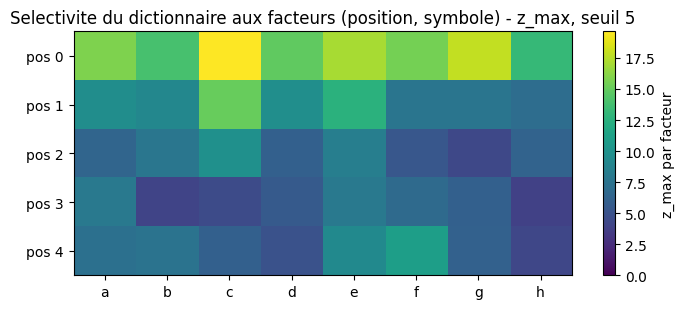

In [6]:
Z_THRESHOLD = 5.0   # z-score au-dela duquel une feature est dite dediee au facteur
N_NULL = 200

factor_names = []
factor_labels = []
for t in range(SEQ_LEN):
    for c in VOCAB:
        factor_names.append((t, c))
        factor_labels.append(np.array([s[t] == c for s, _ in train_data]))

sel = {}          # (t, c) -> resultat factor_selectivity
feat_maxz = np.full(N_FEATURES, -np.inf)
maxz_per_factor = []
auc_top = []
for (t, c), labels in zip(factor_names, factor_labels):
    res = factor_selectivity(z_train, labels, n_null=N_NULL, seed=0)
    sel[(t, c)] = res
    j_star = int(np.argmax(res["z"]))
    maxz_per_factor.append(res["z"][j_star])
    auc_top.append(res["auc"][j_star])
    feat_maxz = np.maximum(feat_maxz, res["z"])

maxz_per_factor = np.array(maxz_per_factor)
dedicated_factors = maxz_per_factor > Z_THRESHOLD
print(f"Facteurs (position, symbole) testes : {len(factor_names)} (chacun ~{int(factor_labels[0].sum())} positifs sur {TRAIN_SAMPLES})")
print(f"Dedies (z_max > {Z_THRESHOLD:.0f} contre null apparie {N_NULL} tirages) : {int(dedicated_factors.sum())}/{len(factor_names)}")
print(f"z_max : mediane = {np.median(maxz_per_factor):.1f} | max = {maxz_per_factor.max():.1f} | min = {maxz_per_factor.min():.1f}")
print(f"AUC de la feature la plus selective par facteur : mediane = {np.median(auc_top):.3f}")

Zmat = maxz_per_factor.reshape(SEQ_LEN, len(VOCAB))
fig, ax = plt.subplots(figsize=(7, 3.2))
im = ax.imshow(Zmat, aspect="auto", cmap="viridis", vmin=0.0)
ax.set_xticks(range(len(VOCAB)))
ax.set_xticklabels(VOCAB)
ax.set_yticks(range(SEQ_LEN))
ax.set_yticklabels([f"pos {t}" for t in range(SEQ_LEN)])
ax.set_title(f"Selectivite du dictionnaire aux facteurs (position, symbole) - z_max, seuil {Z_THRESHOLD:.0f}")
fig.colorbar(im, ax=ax, label="z_max par facteur")
plt.tight_layout()
plt.show()

### Lecture de la confrontation statistique

**Sortie obtenue** : la heatmap donne le z-score maximal du dictionnaire pour chaque facteur (position, symbole) — l'échelle est fixée par 200 relabelisations aléatoires appariées en effectifs (une feature jamais sélective rend z = 0, une feature morte rend AUC = 0.5). Ces z-scores sont une **statistique descriptive** : ils disent « au-delà de ce que le hasard du relabellement produit », sans test d'hypothèse formel ni intervalle de confiance.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| facteurs dédiés | 34/40 au seuil z > 5 | le dictionnaire porte une large part des facteurs au seuil choisi |
| z_max médian | 7.7 (max 19.6, min 3.8) | la sélectivité dépasse le null apparié pour la majorité des facteurs |
| AUC médiane de la meilleure feature | 0.658 | discrimination modérée par facteur — pas une lecture binaire nette |
| structure par position | lignes de la heatmap | la couverture des positions est inégale (les z par ligne varient) |

**Points clés** :

1. La discipline du null apparié (héritage de la série ICT) : une feature ne compte comme dédiée que si son AUC écrase ce que le hasard du relabellement produit — pas de seuil absolu arbitraire.
2. La couverture n'est pas totale (34/40) : quelques facteurs n'ont pas d'atome au-dessus du seuil — cohérent avec le plateau de mélange documenté par l'organe (des atomes polyvalents au lieu d'atomes dédiés).
3. Ce que cette cellule ne dit pas : *sous quelle forme géométrique* la sélectivité est portée — c'est la cellule suivante, et c'est le cœur de la confrontation avec la TPR.

Features dediees a un facteur : 46 | autres : 18
Concentration de rang 1 dans le decoupage (4 x 8) :
  atomes dedies   : 0.552 +/- 0.095   (controle aleatoire : 0.496 +/- 0.093)
  atomes non dedies : 0.480 +/- 0.047   (controle aleatoire : 0.518 +/- 0.078)


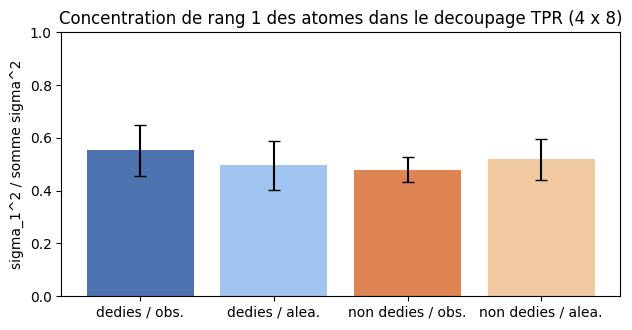

In [7]:
def rank1_concentration(vec, d_role, d_filler):
    """Concentration de rang 1 : part de l'energie dans la premiere valeur singuliere."""
    M = vec.reshape(d_role, d_filler)
    s = np.linalg.svd(M, compute_uv=False)
    return float(s[0] ** 2 / max(float(np.sum(s ** 2)), 1e-12))


dedicated_feats = np.where(feat_maxz > Z_THRESHOLD)[0]
other_feats = np.where(feat_maxz <= Z_THRESHOLD)[0]

# Decoupage conventionnel 4x8 (cellule precedente) : d_role >= 2, la mesure de
# rang 1 est non triviale. Un decoupage 1 x 32 rendrait tout vecteur de rang 1
# par construction -- la garde est verifiee par construction ici.
conc_ded = np.array([rank1_concentration(sae.W_dec[:, j], D_ROLE, D_FILLER) for j in dedicated_feats])
conc_oth = np.array([rank1_concentration(sae.W_dec[:, j], D_ROLE, D_FILLER) for j in other_feats])

# Controle : directions aleatoires uniformes sur la sphere de dimension D_MODEL
# (les colonnes de W_dec sont unit-norm par construction de l'organe).
rng = np.random.default_rng(0)
def _random_unit(n_draws):
    G = rng.normal(size=(n_draws, D_MODEL))
    return G / np.linalg.norm(G, axis=1, keepdims=True)

conc_rand_ded = np.array([rank1_concentration(v, D_ROLE, D_FILLER) for v in _random_unit(len(dedicated_feats))])
conc_rand_oth = np.array([rank1_concentration(v, D_ROLE, D_FILLER) for v in _random_unit(len(other_feats))])

print(f"Features dediees a un facteur : {len(dedicated_feats)} | autres : {len(other_feats)}")
print(f"Concentration de rang 1 dans le decoupage ({D_ROLE} x {D_FILLER}) :")
print(f"  atomes dedies   : {conc_ded.mean():.3f} +/- {conc_ded.std():.3f}   (controle aleatoire : {conc_rand_ded.mean():.3f} +/- {conc_rand_ded.std():.3f})")
print(f"  atomes non dedies : {conc_oth.mean():.3f} +/- {conc_oth.std():.3f}   (controle aleatoire : {conc_rand_oth.mean():.3f} +/- {conc_rand_oth.std():.3f})")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bars = [
    ("dedies / obs.", conc_ded), ("dedies / alea.", conc_rand_ded),
    ("non dedies / obs.", conc_oth), ("non dedies / alea.", conc_rand_oth),
]
xs = np.arange(len(bars))
means = [b[1].mean() for b in bars]
stds = [b[1].std() for b in bars]
ax.bar(xs, means, yerr=stds, capsize=4, color=["#4c72b0", "#a1c4f0", "#dd8452", "#f0c9a1"])
ax.set_xticks(xs)
ax.set_xticklabels([b[0] for b in bars])
ax.set_ylabel("sigma_1^2 / somme sigma^2")
ax.set_title(f"Concentration de rang 1 des atomes dans le decoupage TPR ({D_ROLE} x {D_FILLER})")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Lecture de la confrontation géométrique — la prédiction TPR n'est pas soutenue

**Sortie obtenue** : la prédiction centrale de l'hypothèse TPR — « si les atomes dédiés à un facteur (position, symbole) portent une paire role (X) filler, ils sont proches du rang 1 dans le découpage 4 x 8 » — **n'est pas soutenue** à ces effectifs :

| Population | Concentration observée | Contrôle aléatoire (même découpage) |
|------------|------------------------|--------------------------------------|
| atomes dédiés (46) | 0.552 ± 0.095 | 0.496 ± 0.093 |
| atomes non dédiés (18) | 0.480 ± 0.047 | 0.518 ± 0.078 |

**Points clés** :

1. L'écart entre les moyennes des atomes dédiés et du contrôle aléatoire (~0.06) est du même ordre que la dispersion des deux distributions (~0.09) ; les atomes dédiés sont *légèrement au-dessus* de l'aléatoire, les non-dédiés *légèrement en dessous* — les deux mouvements sont modestes et les distributions larges. **Aucune inférence formelle n'est revendiquée** : c'est un contraste descriptif à effectifs bornés, pas un test. Les ± rapportés sont les écarts-types des populations, pas des erreurs-types.
2. Autrement dit : le dictionnaire SAE *trouve* les facteurs (cellule statistique : 34/40 au-dessus du null apparié) mais la forme géométrique de ces atomes n'est **pas** celle que prédirait naïvement la lecture TPR. Le résultat négatif est informatif en soi — il sépare la *sélectivité* (l'atome sait *quel* facteur) de la *géométrie* (l'atome ne le code pas *comme* un produit tensoriel rôle x filler).
3. Caveat de découpage : la valeur *absolue* dépend du découpage imposé (4 x 8, par convention). La comparaison dédié vs aléatoire, elle, est faite *dans le même découpage* — le contraste est interne et ne dépend pas du choix de découpage, contrairement à la valeur absolue.
4. Ce constat vaut pour ce dictionnaire (une graine), ce découpage et cette échelle : rien n'exclut qu'une structure TPR de rang 1 apparaisse à une autre échelle ou dans un autre espace, mais elle n'est pas visible ici.

In [8]:
H_tpr_val = tpr_reconstruct(H_val, D_ROLE, D_FILLER, TPR_RANK)
if D_ROLE >= 2:
    H_tpr_perm = tpr_reconstruct(H_val, D_ROLE, D_FILLER, TPR_RANK, permute_blocs=True)
else:
    H_tpr_perm = H_tpr_val  # decoupage degénéré : aucun bloc a permuter

# Ablation SAE dirigee : features dediees a un facteur de la position 0.
pos0_feats = set()
for (t, c), res in sel.items():
    if t != 0:
        continue
    j_star = int(np.argmax(res["z"]))
    if res["z"][j_star] > Z_THRESHOLD:
        pos0_feats.add(j_star)
pos0_feats = sorted(pos0_feats)


def sae_ablate(z, feats):
    z2 = z.copy()
    if feats:
        z2[:, list(feats)] = 0.0
    return sae.decode(z2)


H_sae_abl = sae_ablate(z_val, pos0_feats)

# Controle 1 -- cardinalite seule : tirage de meme cardinal parmi les 64.
# Controle 2 -- cardinalite + activite : tirage parmi les features ACTIVES sur
# val (le zero honnete de l'echelle), 20 tirages pour la dispersion.
rng_abl = np.random.default_rng(0)
rand_any = sorted(rng_abl.choice(N_FEATURES, size=len(pos0_feats), replace=False).tolist()) if pos0_feats else []

active_feats = np.where((z_val > 0).any(axis=0))[0]
accs_matched = []
for _ in range(20):
    feats_m = sorted(rng_abl.choice(active_feats, size=len(pos0_feats), replace=False).tolist())
    accs_matched.append(accuracy_with_h(model, val_data, sae_ablate(z_val, feats_m)))
accs_matched = np.array(accs_matched)

acc_orig = accuracy_with_h(model, val_data, H_val)
acc_tpr = accuracy_with_h(model, val_data, H_tpr_val)
acc_perm = accuracy_with_h(model, val_data, H_tpr_perm)
acc_sae = accuracy_with_h(model, val_data, H_sae_val)
acc_abl = accuracy_with_h(model, val_data, H_sae_abl)
acc_rand_any = accuracy_with_h(model, val_data, sae_ablate(z_val, rand_any))

rank_eff = min(TPR_RANK, D_ROLE, D_FILLER)
print(f"features dediees a pos0 : {pos0_feats} | features actives sur val : {len(active_feats)}/{N_FEATURES}")
print()
print(f"{'lecture':<56s} {'acc':>6s} {'delta':>7s}")
rows = [
    ("originale (H)", acc_orig),
    (f"TPR par echantillon (rang effectif {rank_eff}, decoupage {D_ROLE}x{D_FILLER})", acc_tpr),
    ("TPR permutation de blocs (lignes 0<->1)", acc_perm),
    ("SAE recon val (encode-only)", acc_sae),
    (f"SAE ablation pos0 ({len(pos0_feats)} feats dediees)", acc_abl),
    (f"SAE ablation aleatoire quelconque ({len(rand_any)} feats)", acc_rand_any),
    ("SAE ablation aleatoire PARMI ACTIVES (20 tirages)", float(accs_matched.mean())),
]
for name, a in rows:
    print(f"{name:<56s} {a:>6.3f} {acc_orig - a:>7.3f}")
print(f"  dispersion du controle apparie : +/- {accs_matched.std():.3f} (ecart-type descriptif sur 20 tirages)")

features dediees a pos0 : [2, 4, 9, 16, 27, 30, 41, 50] | features actives sur val : 49/64

lecture                                                     acc   delta
originale (H)                                             0.817   0.000
TPR par echantillon (rang effectif 4, decoupage 4x8)      0.817   0.000
TPR permutation de blocs (lignes 0<->1)                   0.346   0.471
SAE recon val (encode-only)                               0.709   0.108
SAE ablation pos0 (8 feats dediees)                       0.532   0.285
SAE ablation aleatoire quelconque (8 feats)               0.563   0.254
SAE ablation aleatoire PARMI ACTIVES (20 tirages)         0.617   0.200
  dispersion du controle apparie : +/- 0.038 (ecart-type descriptif sur 20 tirages)


### Lecture du contraste fonctionnel — deux perturbations de natures différentes

**Sortie obtenue** (remise en cause d'un décodeur sauvegardé : accuracy de val quand on force l'état initial du décodeur) :

| Perturbation | Acc (val) | Delta vs originale | Lecture |
|--------------|-----------|--------------------|---------|
| originale (H) | 0.817 | — | — |
| TPR par échantillon (rang effectif 4) | 0.817 | 0.000 | fidélité : reconstruction exacte (R² = 1) — contrôle de passage |
| permutation des blocs 0<->1 du découpage 4 x 8 | 0.346 | 0.471 | contrôle structurel des coordonnées — **pas** une intervention sur des rôles |
| SAE recon val (encode-only) | 0.709 | 0.108 | fidélité du dictionnaire à val |
| ablation SAE des 8 features dédiées à pos0 | 0.532 | 0.285 | ablation dirigée (sémantique) |
| ablation de 8 features au hasard | 0.563 | 0.254 | un tirage quelconque |
| ablation de 8 features PARMI ACTIVES (20 tirages) | 0.617 ± 0.038 | 0.200 | zéro honnête de l'échelle (dispersion descriptive) |

**Points clés** :

1. **Permutation de blocs** : échanger les deux premiers blocs de coordonnées du reshape 4 x 8 fait chuter l'accuracy de 0.817 à 0.346 (delta 0.47). Lecture : les coordonnées de `H`, telles que le décodeur les lit, ne sont **pas interchangeables** — leur ré-agencement détruit l'information. C'est cohérent avec une organisation fine des coordonnées, mais cela **ne démontre aucune structure de rôles apprise** : le découpage 4 x 8 est une convention, et permuter des lignes d'un reshape n'est pas une intervention sur des rôles — c'est un **contrôle structurel** que l'on mesure pour situer l'échelle des perturbations. Il serait illégitime d'en tirer « les rôles TPR portent la fonction » ; il est légitime d'en tirer « le décodeur lit des coordonnées spécifiques avec des significations spécifiques ».
2. **Ablation dirigée SAE** : supprimer les 8 features dédiées à la position 0 coûte 0.285 d'accuracy (0.817 -> 0.532), plus que la référence appariée en activité (0.617 ± 0.038 ; excédent d'environ 0.085, soit environ deux fois la dispersion des 20 tirages). C'est un **effet conditionnel exploratoire** : un sous-ensemble sémantiquement choisi ruine la lecture plus qu'un tirage de même cardinal parmi les features actives, dans les conditions mesurées (ce dictionnaire, ce découpage de lecture, ce décodeur). La dispersion rapportée est celle des tirages — descriptive, pas une erreur-type inférentielle.
3. Le contrôle « au hasard quelconque » (0.563) est *plus bas* que le contrôle apparié en activité (0.617) : un tirage uniforme tape parfois des features très actives ou rares qui coûtent plus cher. C'est pourquoi le zéro honnête est le tirage **parmi les actives**, et l'on rapporte les deux pour que le lecteur voie la sensibilité au protocole de contrôle.
4. La position 0, sous le protocole BOS, est la cible produite *en premier*, à partir de BOS et de `H` seuls : c'est le cas le plus pur où la cible ne peut venir que de `H`. Sa perte sous ablation est donc particulièrement lisible — l'information de pos0 est portée, au moins en partie, par les features que le dictionnaire lui dédie.
5. Ce que ce contraste **ne dit pas** : il ne localise pas un « facteur » à une coordonnée (l'ablation retire des atomes *appris*, pas des rôles) et l'ordre de grandeur des deltas dépend du découpage conventionnel et du décodeur ; c'est une échelle de coûts fonctionnels, pas une localisation causale.

In [9]:
# TPR partagee (apprise sur train) appliquee a val : une seule reconstruction pour tous.
shared = np.einsum("rg,gf->rf", R_mean, F_mean).flatten()
H_tpr_shared_val = np.broadcast_to(shared, H_val.shape)

rank_eff = min(TPR_RANK, D_ROLE, D_FILLER)
gen_rows = [
    ("originale (H)", accuracy_with_h(model, val_data, H_val), "-"),
    ("SAE : dictionnaire train, codes val", accuracy_with_h(model, val_data, H_sae_val), f"FVU val = {fvu_val:.4f}"),
    ("TPR partagee (R_mean, F_mean de train)", accuracy_with_h(model, val_data, H_tpr_shared_val), "une seule reconstruction pour toutes les sequences"),
    (f"TPR par echantillon (rang effectif {rank_eff})", accuracy_with_h(model, val_data, H_tpr_val), "factorisee sur l'echantillon lui-meme"),
]

print(f"{'lecture':<46s} {'acc':>6s}   note")
for name, a, note in gen_rows:
    print(f"{name:<46s} {a:>6.3f}   {note}")
print()
print(f"FVU SAE : train = {sae_out['fvu']:.4f} | val = {fvu_val:.4f} | ecart = {fvu_val - sae_out['fvu']:+.4f}")

lecture                                           acc   note
originale (H)                                   0.817   -
SAE : dictionnaire train, codes val             0.709   FVU val = 0.1032
TPR partagee (R_mean, F_mean de train)          0.135   une seule reconstruction pour toutes les sequences
TPR par echantillon (rang effectif 4)           0.817   factorisee sur l'echantillon lui-meme

FVU SAE : train = 0.0746 | val = 0.1032 | ecart = +0.0285


### Lecture de la généralisation — le SAE transfère, la TPR partagée s'effondre

**Sortie obtenue** (train vers val, sans ré-entraînement) :

| Lecture | Acc (val) | Note |
|---------|-----------|------|
| SAE : dictionnaire entraîné sur train, codes val | 0.709 | FVU val = 0.1032 (écart train +0.0285) |
| TPR partagée (R̄, F̄ de train) | 0.135 | une seule reconstruction pour toutes les séquences |
| TPR par échantillon (rang effectif 4) | 0.817 | factorise l'échantillon lui-même — plafond local, pas un transfert |

**Points clés** :

1. Le vrai transfert train vers val est celui du **dictionnaire SAE** : appris sur les 800 états de train, appliqué sans ré-entraînement aux 200 états de val — l'accuracy ne tombe que de 0.817 à 0.709, et la FVU ne se dégrade que de +0.03. Le dictionnaire capte des directions qui survivent au changement d'échantillons : c'est une forme de généralisation *mesurée*.
2. La TPR *partagée* s'effondre (0.135, quasi le hasard) : une seule matrice de rôles/fillers moyens ne peut pas servir de reconstruction à toutes les séquences — la TPR utile est nécessairement *par échantillon*, donc sans objet appris transférable. C'est la différence structurelle la plus nette entre les deux lectures à cette échelle : le dictionnaire **apprend un vocabulaire réutilisable**, la TPR découvre une factorisation **à la demande**.
3. Le 0.817 « par échantillon » n'est pas un résultat de généralisation : à rang effectif 4 en 4 x 8, la SVD est exacte (R² = 1), donc la reconstruction est l'identité — c'est le plafond de ce que le décodage d'un `H` exact permet, utile comme point haut de l'échelle.
4. Bornage : « généralisation » ici = même distribution (nouvelles séquences de copy), pas un transfert de tâche. Un transfert vers une autre tâche (copy -> reverse) est justement l'Exercice 1.

## Conclusion

**Question posée** : les deux lectures concurrentes des mêmes états cachés — TPR imposée (SL-13) vs dictionnaire SAE appris (série ICT) — voient-elles la même structure dans `H` ?

**Ce qui est mesuré** (tout en CPU, quelques secondes par cellule, tout est seedé et reproductible) :

| Question | Résultat mesuré | Statut |
|----------|------------------|--------|
| Le dictionnaire porte-t-il les facteurs (position, symbole) ? | 34/40 facteurs dédiés à z > 5 contre null apparié ; AUC médiane 0.658 | descriptif : oui, au seuil choisi |
| Les atomes dédiés sont-ils proches du rang 1 (prédiction TPR) ? | dédiés 0.552 ± 0.095 vs aléatoire 0.496 ± 0.093 — écart du même ordre que la dispersion | **non soutenu** : contraste exploratoire, sans inférence |
| Les coordonnées de `H` sont-elles interchangeables ? | permutation de blocs : 0.817 -> 0.346 (delta 0.47) | non — mais c'est un contrôle structurel, pas une preuve de rôles |
| L'ablation SAE dirigée coûte-t-elle plus que son contrôle ? | pos0 : delta 0.285 vs référence appariée 0.617 ± 0.038 — excédent ~0.085 | effet conditionnel exploratoire |
| Le transfert train -> val ? | SAE 0.709 (FVU +0.03) ; TPR partagée 0.135 | transfert mesuré côté SAE ; effondrement côté TPR |

**Ce que l'on retient** :

1. **Les deux lectures ne voient pas la même chose.** Le dictionnaire *trouve* des atomes sélectifs aux facteurs et un vocabulaire qui transfère ; il ne les organise *pas* comme les paires rôle x filler que prédirait l'hypothèse TPR (rang 1 non soutenu). La convergence porte sur l'existence d'une factorisation par facteurs, pas sur sa géométrie.
2. **La prédiction falsifiable a été testée et n'est pas soutenue à cette échelle** — c'est le résultat le plus fort du notebook, et il est négatif. À effectifs bornés, la structure TPR « approximative » de SL-13 n'est pas la forme sous laquelle un dictionnaire creux lit `H`.
3. **Les perturbations fonctionnelles sont de deux natures différentes** : la permutation des blocs de coordonnées (contrôle structurel — pas une surgery sur des rôles appris) détruit massivement la lecture, montrant que les coordonnées de `H` sont porteuses et non échangeables ; l'ablation SAE dirigée (sémantique) coûte plus cher que son contrôle apparié en activité, dans les limites du découpage conventionnel et des effectifs.
4. **Le protocole de décodage a été corrigé et re-mesuré** (BOS en entrée du décodeur, cible complète) : chaque position — y compris la position 0 — est une cible de prédiction, le symbole cible n'étant jamais visible au moment de le prédire. L'évaluation reste teacher-forced : elle compare des lectures entre elles, elle ne qualifie pas la génération libre.
5. **Bornes explicites** : échelle CPU, une tâche (copy), un découpage 4 x 8 conventionnel, une seule graine par entraînement ; les écarts rapportés sont descriptifs (moyennes et dispersions sur tirages), sans test inférentiel. GWT et grandes échelles restent hors de cette tranche (EPIC #14366) — ce que ce notebook propose, c'est un banc *falsifiable* sur lequel une passe à plus grande échelle peut rejouer exactement les mêmes mesures.

**Prolongements naturels** : les trois exercices (reverse, ablation par symbole et mort douce, sur-complétude 32/64/128) ; le registre axe-2 SOTA de l'EPIC #14366 pour le verdict de richesse.

## Exercice 1 — Le contraste sur la tâche reverse

**Énoncé** : SL-13 observait que la tâche reverse tire le plus grand bénéfice de la structure TPR (les rôles de sortie sont le miroir des rôles d'entrée). Refaites la batterie de ce notebook (TPR par échantillon au rang demandé 5, SAE, sélectivité, rang 1, permutation de blocs, ablations) sur une tâche reverse — en conservant le protocole BOS (entrée du décodeur `[BOS] + cible[:-1]`, cible complète).

**Piste** : la fonction de génération est dans SL-13 ; recopiez-la telle quelle, remplacez `make_copy_task`, et rebranchez `encode_batch` sur la nouvelle paire (entrée, cible). Gardez tous les autres paramètres identiques — la comparabilité est le point de l'exercice.

**Indice** : surveillez la ligne « pos 0 » de la heatmap de sélectivité. En copy, la position 0 est la première cible produite (le décodeur n'a vu que BOS et `H`) ; en reverse, c'est la *dernière* cible. Si la couverture des positions change du côté SAE mais pas du côté TPR (ou l'inverse), vous tenez une différence structurale entre les deux lectures — dites laquelle et pourquoi.

## Exercice 2 — Ablation dirigée par symbole et perturbation « douce »

**Énoncé** : la cellule de confrontation fonctionnelle a ablaté les features dédiées à une *position* (tous symboles confondus). Construisez maintenant l'ablation dirigée par *symbole* : les features dédiées au facteur « le symbole c est présent dans la séquence » (toutes positions confondues, label = `c in s`), puis prédisez AVANT de mesurer : quelles cibles de prédiction doivent mourir, et est-ce la même chose que ce que ferait une vraie TPR en supprimant le filler c de tous les rôles ?

**Piste** : pour le label par symbole, `np.array([c in s for s, _ in train_data])` donne le facteur présence ; la machinery `factor_selectivity` et l'ablation se recollent telles quelles.

**Indice** : testez aussi la variante « douce » — remplacer les codes ablatés par leur moyenne d'entraînement au lieu de zéro (`z2[:, feats] = z_train[:, feats].mean(axis=0)`). Si la mort douce coûte moins cher que la mort brutale, une partie de la chute mesurée était un artefact d'extrapolation hors distribution du décodeur, pas un portage du facteur. Et gardez en tête la limite du découpage : permuter des blocs de coordonnées dans un reshape arbitraire n'est PAS une intervention sur des rôles appris — construire un alignement de rôles appris (par exemple en regroupant les fillers par échantillon puis en appariant les centroïdes aux positions) serait la vraie extension.

## Exercice 3 — Sur-complétude : 32, 64, 128 atomes

**Énoncé** : le dictionnaire de ce notebook est sur-complet x2 (64 atomes pour d = 32). Refaites l'entraînement SAE à `n_features` dans {32, 64, 128} à `k = 8` fixe, et mesurez pour chaque cardinalité : FVU train/val, la fraction d'atomes dédiés à un facteur, et leur concentration de rang 1 moyenne.

**Piste** : trois appels à `train_sae` avec la même graine, puis recollez `feat_maxz` et les concentrations comme dans les cellules de confrontation — le tout tient en une boucle.

**Indice** : l'organe documente un **plateau de mélange** — sur un corpus exactement reconstructible, l'entraînement full-batch retrouve ~17/24 atomes propres et laisse les autres en combinaisons. Si la fraction d'atomes dédiés augmente avec la sur-complétude mais que leur concentration de rang 1 *stagne ou baisse*, les atomes supplémentaires capturent les facteurs en les *mélangeant* — et vous pourrez dire laquelle des deux lectures (structure imposée TPR vs dictionnaire libre) vieillit le mieux quand la capacité croît.

## Résumé

- **Confrontation TPR x SAE** : deux factorisations concurrentes du même état caché — la TPR impose des paires rôle (X) filler additionnées (structure), le SAE impose une combinaison creuse d'atomes appris (liberté).
- **Protocole BOS** : l'entrée du décodeur est `[BOS] + séquence[:-1]` et la cible est complète — chaque position est une cible de prédiction, et le symbole cible n'est jamais visible au moment de le prédire ; l'évaluation reste teacher-forced (convention du harnais, pour comparer des lectures entre elles).
- **Sélectivité aux facteurs** : AUC de Mann-Whitney par feature contre chaque label (position, symbole), z-score contre null apparié en effectifs — statistique descriptive, héritage de l'organe `ict.sae_dictionary`.
- **Prédiction géométrique falsifiable** : si la structure TPR portait les atomes, les atomes *dédiés* à un facteur seraient proches du rang 1 dans le découpage (d_role x d_filler) — la mesure ne la soutient pas à ces effectifs (verdict exploratoire, sans inférence formelle).
- **Deux perturbations de natures différentes** : permutation des premiers blocs de coordonnées du découpage TPR (contrôle structurel — pas une intervention sur des rôles appris) contre ablation SAE dirigée (suppression sémantique), chacune située contre son contrôle apparié.
- **Transfert honnête** : dictionnaire appris sur train, appliqué à val (encode-only) contre TPR partagée ; la TPR par échantillon est un plafond local, pas une généralisation.
- **Conclusion bornée** : évidences descriptives convergentes et divergentes entre deux lectures, à échelle CPU — jamais l'identification d'un mécanisme ni un test inférentiel ; GWT et grande échelle hors scope (EPIC #14366, prolongement proposé en commentaire du 2026-09-05).

**Références** :

- R. Thomas McCoy, Paul Soulos, Tal Linzen, Paul Smolensky, *The Emergent Symbolic Structure of Artificial Neural Networks*, [arXiv:2608.29530](https://arxiv.org/abs/2608.29530).
- Organe SAE : `MyIA.AI.Notebooks/IIT/ICT-Series/ict/sae_dictionary.py` — entraînement top-k, sélectivité contre null apparié (série ICT, issue #15480).

**Crédits EPIC** : sous-grain du claim #14366 (c.5868227133) — confrontation TPR (SL-13) x dictionnaire SAE existant, CPU borné ; GWT explicitement hors de cette tranche atomique.